# SEAAS-Net Reproducibility Notebook

This notebook reproduces the Dresden dataset evaluation results reported in the paper

**SEAAS-Net: Squeeze-Excitation Attention with Adaptive Suppression for Source Camera Identification**

The notebook performs the following steps:

1. Loads the pretrained SEAAS-Net model.
2. Loads the released Dresden test patches.
3. Performs patch-level prediction.
4. Applies majority voting for image-level prediction.
5. Reports the evaluation metrics.
6. Displays the image-level confusion matrix.

## Required Kaggle Resources

Attach the following public Kaggle resources before running this notebook.

### Model

https://www.kaggle.com/models/rahulrawatgujjar/best-seaas-model

### Dataset

https://www.kaggle.com/datasets/rahulrawatgujjar/dresden-test-patches

# Import libraries

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import mixed_precision
from tensorflow.keras.preprocessing import image_dataset_from_directory
import sys
import os
import importlib.util

# Load custom layers
The pretrained model contains custom TensorFlow layers.
Their compiled implementation is provided with the model package and is loaded automatically before model loading.

In [10]:
# Model path
model_path = 'seaasnet_dresden_files'

so_path = os.path.join(model_path, 'custom_layers.so')
spec = importlib.util.spec_from_file_location("custom_layers", so_path)
custom_layers = importlib.util.module_from_spec(spec)
spec.loader.exec_module(custom_layers)

SEBlock = custom_layers.SEBlock
SEAASBlock = custom_layers.SEAASBlock

model_path = os.path.join(model_path, 'seaasnet_dresden.keras')
print(f"Model exists: {os.path.exists(model_path)}")

Model exists: True


# Load the pretrained model

In [4]:
mixed_precision.set_global_policy("mixed_float16")

model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        "SEAASBlock": SEAASBlock,
        "SEBlock": SEBlock
    }
)

print(f"Model : {model.name}")
print("SEAAS-Net model loaded successfully.")

Model : SEAASNet
SEAAS-Net model loaded successfully.


# Test dataset path

In [5]:
test_dir = "dresden_test_patches"

img_size = (64, 64)
batch_size = 100

# Helper function

In [6]:
def get_image_id(filename):
    base = os.path.basename(filename)
    return "_".join(base.split("_")[:-1])

# Load test dataset

In [7]:
raw_test_ds = image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = raw_test_ds.class_names
file_paths = raw_test_ds.file_paths

test_ds = raw_test_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)
)

true_labels = [
    class_names.index(os.path.basename(os.path.dirname(fp)))
    for fp in file_paths
]
print(f"Number of classes : {len(class_names)}")
print(f"Number of patches : {len(file_paths)}")

Found 130000 files belonging to 26 classes.
Number of classes : 26
Number of patches : 130000


# Predict

In [8]:
import numpy as np

pred_probs = model.predict(test_ds, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)

E0000 00:00:1782801532.053198    9666 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


1300/1300 ━━━━━━━━━━━━━━━━━━━━ 1376s 1s/step


# Majority voting

In [35]:
from collections import defaultdict

image_preds = defaultdict(list)
image_probs = defaultdict(list)
image_truth = {}

for fp, y_true, probs, y_pred in zip(
    file_paths,
    true_labels,
    pred_probs,
    pred_labels
):
    img_id = get_image_id(fp)

    image_preds[img_id].append(y_pred)
    image_probs[img_id].append(probs)
    image_truth[img_id] = y_true


final_preds = {}

for img_id, preds in image_preds.items():
    counts = np.bincount(preds, minlength=len(class_names))
    final_preds[img_id] = np.argmax(counts)

final_probs = {}

for img_id, probs in image_probs.items():
    final_probs[img_id] = np.mean(probs, axis=0)

# Compute Metrics

In [36]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_true_img = np.array([image_truth[k] for k in final_preds.keys()])
y_pred_img = np.array([final_preds[k] for k in final_preds.keys()])

image_acc = accuracy_score(y_true_img, y_pred_img)

print("\nEvaluation Results")
print("-" * 50)
print(f"Patch-Level Accuracy : {(pred_labels == true_labels).mean()*100:.2f}%")
print(f"Image-Level Accuracy : {image_acc*100:.2f}%")
print("-" * 50)

print(classification_report(
    y_true_img,
    y_pred_img,
    target_names=class_names,
    digits=4
))


Evaluation Results
--------------------------------------------------
Patch-Level Accuracy : 84.92%
Image-Level Accuracy : 90.62%
--------------------------------------------------
                       precision    recall  f1-score   support

        Agfa_DC-504_0     0.4699    0.7800    0.5865        50
         Agfa_DC-733s     1.0000    1.0000    1.0000        50
       Agfa_DC-830i_0     1.0000    0.9800    0.9899        50
   Agfa_Sensor505-x_0     1.0000    1.0000    1.0000        50
    Agfa_Sensor530s_0     1.0000    0.1000    0.1818        50
       Canon_Ixus55_0     0.9038    0.9400    0.9216        50
       Canon_Ixus70_0     1.0000    0.9200    0.9583        50
  Canon_PowerShotA640     0.9400    0.9400    0.9400        50
      Casio_EX_Z150_0     0.8929    1.0000    0.9434        50
FujiFilm_FinePixJ50_0     1.0000    1.0000    1.0000        50
        Kodak_M1063_0     1.0000    1.0000    1.0000        50
  Nikon_CoolPixS710_0     0.9804    1.0000    0.9901        5

# Confusion Matrix

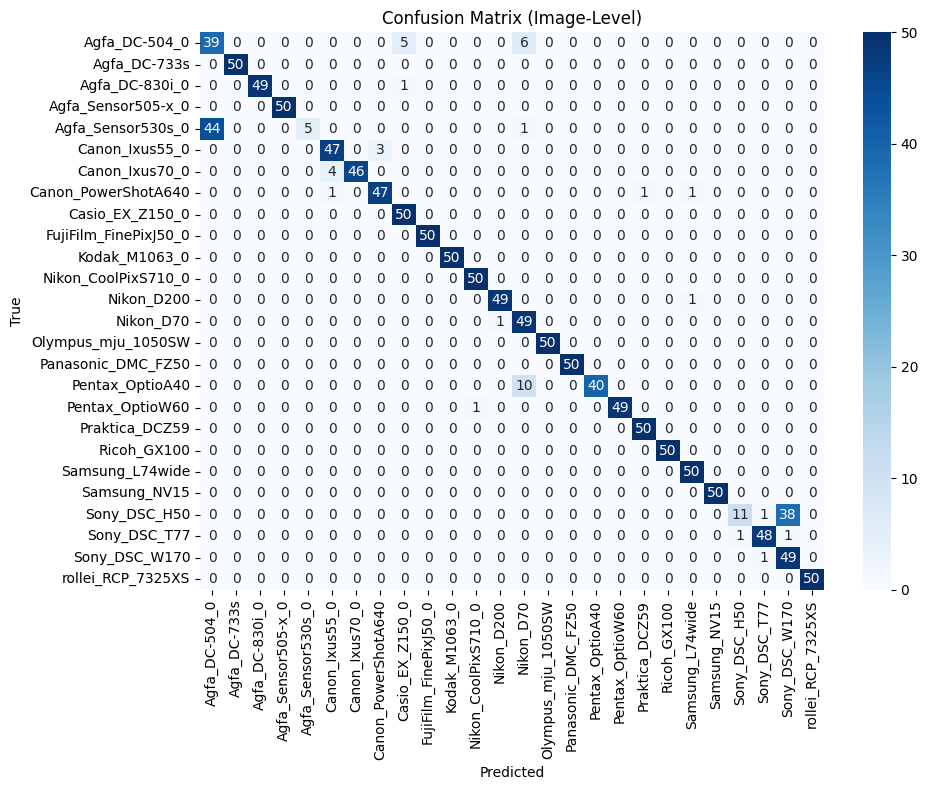

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_img, y_pred_img)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Image-Level)")
plt.tight_layout()
plt.show()

## Results

The notebook should reproduce the Dresden dataset evaluation reported in the paper.

Expected performance:

- Patch-Level Accuracy: **84.92%**
- Image-Level Accuracy: **90.62%**